# Evaluierung des DPO-Übersetzungsmodells auf dem Lebenshilfe-Datensatz
### Masterarbeit: Automatische Übersetzung von Alltagssprache (AS) in Leichte Sprache (LS)

Dieses Notebook evaluiert das mit **Direct Preference Optimization (DPO)** trainierte Übersetzungsmodell auf dem unabhängigen **Lebenshilfe-Testdatensatz**:
1. **DPO-Modell laden:** Lädt die trainierten LoRA-Adapter aus dem DPO-Modellordner (`results/models/dpo_trained_model`) und hängt sie an das SFT-Basismodell (`results/models/new_pipeline/sft`).
2. **Reward- & Metrik-Setup:**
   - **Stil & Einfachheit ($R_{\text{style}}$):** BiLSTM Synthetic Regressor.
   - **Semantische Ähnlichkeit ($R_{\text{sem}}$):** Sentence-BERT Ähnlichkeit zur AS-Quelle.
   - **Referenz-Treue:** SBERT Ähnlichkeit zur echten menschlichen LS-Referenz.
   - **Composite Reward:** Kombinierter Qualitäts-Score.
3. **Batch-Übersetzung** aller Artikel des Lebenshilfe-Datensatzes (ohne Prompt-Prefix).
4. **Quantitative & Statistische Auswertung** (inkl. direktem Vergleich zu SFT falls vorhanden).
5. **Qualitatives Stichproben-Audit** & Interaktive Übersetzung.

In [1]:
import os
import sys
import json
import glob
import random
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import spacy
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
from peft import PeftModel
from sentence_transformers import SentenceTransformer, util

# Arbeitsverzeichnis auf Projekt-Root setzen
while not os.path.exists(".git"):
    parent = os.path.dirname(os.getcwd())
    if parent == os.getcwd():
        break
    os.chdir("..")

print("Arbeitsverzeichnis:", os.getcwd())
DEVICE = torch.device("cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu"))
print(f"Nutze Device: {DEVICE}")

Arbeitsverzeichnis: /home/fiete/master-thesis
Nutze Device: cuda


In [2]:
# ==============================================================================
# ZENTRALE KONFIGURATION & PFADE
# ==============================================================================
SFT_MODEL_PATH = "results/models/new_pipeline/sft"
DPO_MODEL_PATH = "results/models/dpo_trained_model"

# Lebenshilfe Datensatz-Pfad (mit Fallback)
LH_PATHS = [
    "data/new_pipeline/lebenshilfe/lebenshilfe_dataset_clean.json",
    "data/new_pipeline/lebenshilfe/lebenshilfe_dataset.json",
    "data/lebenshilfe/lebenshilfe_dataset.json"
]
LH_DATASET_PATH = next((p for p in LH_PATHS if os.path.exists(p)), LH_PATHS[0])

# Reward Model & Vocab Pfade (mit Fallback)
REWARD_MODEL_PATHS = [
    "results/models/bilstm_synthetic_regression.pt",
    "results/models/best_bilstm_regressor.pt"
]
REWARD_MODEL_PATH = next((p for p in REWARD_MODEL_PATHS if os.path.exists(p)), REWARD_MODEL_PATHS[0])

VOCAB_PATHS = [
    "data/vocabs/synthetic_vocab.json",
    "data/new_pipeline/vocabs/synthetic_vocab.json",
    "data/vocabs/mixup_vocab.json"
]
REWARD_VOCAB_PATH = next((p for p in VOCAB_PATHS if os.path.exists(p)), VOCAB_PATHS[0])

SBERT_MODEL_NAME = "sentence-transformers/paraphrase-multilingual-mpnet-base-v2"

W_STYLE = 0.5
W_SEM = 0.5
MAX_SOURCE_LEN = 256
MAX_TARGET_LEN = 256

print(f"SFT Basis-Ordner:     {SFT_MODEL_PATH}")
print(f"DPO Modell-Ordner:    {DPO_MODEL_PATH}")
print(f"Lebenshilfe-Datensatz: {LH_DATASET_PATH}")
print(f"Reward Modell:         {REWARD_MODEL_PATH}")
print(f"Reward Vokabular:      {REWARD_VOCAB_PATH}")

SFT Basis-Ordner:     results/models/new_pipeline/sft
DPO Modell-Ordner:    results/models/dpo_trained_model
Lebenshilfe-Datensatz: data/new_pipeline/lebenshilfe/lebenshilfe_dataset_clean.json
Reward Modell:         results/models/bilstm_synthetic_regression.pt
Reward Vokabular:      data/vocabs/synthetic_vocab.json


## 1. DPO-Modell & Tokenizer aus Ordner laden

In [3]:
print(f"Lade Tokenizer aus: {DPO_MODEL_PATH}...")
try:
    tokenizer = AutoTokenizer.from_pretrained(DPO_MODEL_PATH, use_fast=False)
except Exception:
    tokenizer = AutoTokenizer.from_pretrained(SFT_MODEL_PATH, use_fast=False)

print(f"Lade SFT-Basismodell aus Ordner: {SFT_MODEL_PATH}...")
base_model = AutoModelForSeq2SeqLM.from_pretrained(SFT_MODEL_PATH).to(DEVICE)

# DPO LoRA Adapter oder vollständiges Modell laden
if os.path.exists(os.path.join(DPO_MODEL_PATH, "adapter_config.json")):
    print(f"Lade DPO LoRA-Adapter aus Ordner: {DPO_MODEL_PATH}...")
    dpo_model = PeftModel.from_pretrained(base_model, DPO_MODEL_PATH).to(DEVICE)
    print("DPO LoRA-Adapter erfolgreich geladen und an SFT-Basismodell angehängt!")
else:
    print(f"Lade vollständiges DPO-Modell aus Ordner: {DPO_MODEL_PATH}...")
    dpo_model = AutoModelForSeq2SeqLM.from_pretrained(DPO_MODEL_PATH).to(DEVICE)

dpo_model.eval()
tokenizer.src_lang = "de_DE"
tokenizer.tgt_lang = "de_DE"
print("Modell-Initialisierung abgeschlossen!")

Lade Tokenizer aus: results/models/dpo_trained_model...
Lade SFT-Basismodell aus Ordner: results/models/new_pipeline/sft...
Lade DPO LoRA-Adapter aus Ordner: results/models/dpo_trained_model...
DPO LoRA-Adapter erfolgreich geladen und an SFT-Basismodell angehängt!
Modell-Initialisierung abgeschlossen!


## 2. Reward-Evaluator & SBERT Setup

In [4]:
class BiLSTMRegressor(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=128, dropout=0.3):
        super(BiLSTMRegressor, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden_dim * 2, 1)
        self.dropout = nn.Dropout(dropout)
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, x):
        embedded = self.dropout(self.embedding(x))
        _, (hidden, _) = self.lstm(embedded)
        hidden = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)
        out = self.fc(self.dropout(hidden))
        return self.sigmoid(out)

# Vokabular laden
with open(REWARD_VOCAB_PATH, "r", encoding="utf-8") as f:
    vocab_data = json.load(f)
    reward_stoi = vocab_data.get("stoi", vocab_data)

bilstm_model = BiLSTMRegressor(len(reward_stoi), embed_dim=128, hidden_dim=128)
if os.path.exists(REWARD_MODEL_PATH):
    raw_state = torch.load(REWARD_MODEL_PATH, map_location="cpu")
    if isinstance(raw_state, dict):
        raw_state = raw_state.get("model_state_dict", raw_state.get("state_dict", raw_state))
    bilstm_model.load_state_dict(raw_state)
    bilstm_model.eval()
    print(f"BiLSTM Regressor erfolgreich geladen von: {REWARD_MODEL_PATH}")
else:
    print(f"Warnung: Reward Modell {REWARD_MODEL_PATH} nicht gefunden.")

try:
    nlp = spacy.load("de_core_news_sm", disable=["ner", "tagger", "lemmatizer"])
except Exception:
    nlp = spacy.blank("de")
    nlp.add_pipe("sentencizer")

def predict_simplicity_score(texts):
    scores = []
    unk_idx = reward_stoi.get("<unk>") or reward_stoi.get("<UNK>") or 1
    for text in texts:
        doc = nlp(str(text or ""))
        tokens = [t.text.lower() for t in doc if not t.is_space]
        indices = [reward_stoi.get(t, unk_idx) for t in tokens[:150]]
        if len(indices) == 0:
            indices = [0]
        inp_tensor = torch.tensor([indices], dtype=torch.long, device="cpu")
        with torch.no_grad():
            score = bilstm_model(inp_tensor).item()
        scores.append(score)
    return np.array(scores)

print(f"Lade SBERT Modell: {SBERT_MODEL_NAME}...")
sbert_model = SentenceTransformer(SBERT_MODEL_NAME, device="cpu")

def predict_semantic_similarity(source_texts, generated_texts):
    emb_src = sbert_model.encode(source_texts, convert_to_tensor=True, show_progress_bar=False)
    emb_gen = sbert_model.encode(generated_texts, convert_to_tensor=True, show_progress_bar=False)
    cosine_sims = util.cos_sim(emb_src, emb_gen).diagonal().cpu().numpy()
    return cosine_sims

class CompositeRewardEvaluator:
    def __init__(self, w_style=0.5, w_sem=0.5):
        self.w_style = w_style
        self.w_sem = w_sem
        
    def compute_reward(self, source_texts, generated_texts):
        r_style = predict_simplicity_score(generated_texts)
        r_sem = predict_semantic_similarity(source_texts, generated_texts)
        r_sem_norm = np.clip((r_sem + 1.0) / 2.0, 0.0, 1.0)
        total_reward = self.w_style * r_style + self.w_sem * r_sem_norm
        return total_reward, r_style, r_sem_norm

reward_evaluator = CompositeRewardEvaluator(w_style=W_STYLE, w_sem=W_SEM)
print("Reward Evaluator erfolgreich initialisiert!")

BiLSTM Regressor erfolgreich geladen von: results/models/bilstm_synthetic_regression.pt
Lade SBERT Modell: sentence-transformers/paraphrase-multilingual-mpnet-base-v2...
Reward Evaluator erfolgreich initialisiert!


## 3. Lebenshilfe-Datensatz laden & DPO-Übersetzungen generieren

In [5]:
with open(LH_DATASET_PATH, "r", encoding="utf-8") as f:
    lh_data = json.load(f)

print(f"Lebenshilfe Datensatz geladen: {len(lh_data)} Artikel-Paare.")

def evaluate_dpo_on_lebenshilfe(model, tokenizer, lh_data, evaluator, batch_size=8):
    model.eval()
    as_texts = [str(item.get("as_text") or "").strip() for item in lh_data]
    ls_ref_texts = [str(item.get("ls_text") or "").strip() for item in lh_data]
    
    forced_bos_id = tokenizer.lang_code_to_id.get("de_DE", None) if hasattr(tokenizer, "lang_code_to_id") else None
    
    gen_texts = []
    for i in tqdm(range(0, len(as_texts), batch_size), desc="Generiere DPO-Übersetzungen"):
        batch_src = as_texts[i : i + batch_size]
        inputs = tokenizer(batch_src, padding=True, truncation=True, max_length=MAX_SOURCE_LEN, return_tensors="pt").to(DEVICE)
        
        with torch.no_grad():
            outputs = model.generate(
                input_ids=inputs["input_ids"],
                attention_mask=inputs.get("attention_mask"),
                max_length=MAX_TARGET_LEN,
                num_beams=4,
                repetition_penalty=2.5,
                no_repeat_ngram_size=3,
                early_stopping=True,
                forced_bos_token_id=forced_bos_id
            )
        decoded = tokenizer.batch_decode(outputs, skip_special_tokens=True)
        gen_texts.extend([d.strip() for d in decoded])
        
    print("Berechne Reward- und Ähnlichkeitsmetriken...")
    tot_reward, r_style, r_sem_norm = evaluator.compute_reward(as_texts, gen_texts)
    sim_to_ref = predict_semantic_similarity(ls_ref_texts, gen_texts)
    sim_to_ref_norm = np.clip((sim_to_ref + 1.0) / 2.0, 0.0, 1.0)
    
    df_res = pd.DataFrame({
        "as_text": as_texts,
        "ls_reference": ls_ref_texts,
        "dpo_translation": gen_texts,
        "simplicity_score": r_style,
        "sbert_sim_to_as": r_sem_norm,
        "sbert_sim_to_ref": sim_to_ref_norm,
        "composite_reward": tot_reward,
        "as_char_len": [len(t) for t in as_texts],
        "gen_char_len": [len(t) for t in gen_texts]
    })
    return df_res

dpo_eval_df = evaluate_dpo_on_lebenshilfe(dpo_model, tokenizer, lh_data, reward_evaluator)

Lebenshilfe Datensatz geladen: 44 Artikel-Paare.


Generiere DPO-Übersetzungen:   0%|          | 0/6 [00:00<?, ?it/s]

Berechne Reward- und Ähnlichkeitsmetriken...


## 4. Statistische Gesamtauswertung (DPO)

In [6]:
print("\n=================== DPO EVALUIERUNGSERGEBNISSE (LEBENSHILFE) ===================")
print(f"Ø Simplicity-Score (R_style):       {dpo_eval_df['simplicity_score'].mean():.4f} ± {dpo_eval_df['simplicity_score'].std():.4f}")
print(f"Ø SBERT-Ähnlichkeit zur AS-Quelle:  {dpo_eval_df['sbert_sim_to_as'].mean():.4f} ± {dpo_eval_df['sbert_sim_to_as'].std():.4f}")
print(f"Ø SBERT-Ähnlichkeit zu LS-Referenz: {dpo_eval_df['sbert_sim_to_ref'].mean():.4f} ± {dpo_eval_df['sbert_sim_to_ref'].std():.4f}")
print(f"Ø Composite Reward:                 {dpo_eval_df['composite_reward'].mean():.4f} ± {dpo_eval_df['composite_reward'].std():.4f}")
print("=================================================================================\n")

# Statistische Kennzahlen anzeigen
metrics_cols = ["simplicity_score", "sbert_sim_to_as", "sbert_sim_to_ref", "composite_reward"]
display(dpo_eval_df[metrics_cols].describe())

# CSV-Export der Ergebnisse
os.makedirs("results", exist_ok=True)
csv_out_path = "results/dpo_lebenshilfe_evaluation.csv"
dpo_eval_df.to_csv(csv_out_path, index=False, encoding="utf-8")
print(f"Detaillierte Evaluierungsergebnisse gespeichert unter: {csv_out_path}")


=================== DPO EVALUIERUNGSERGEBNISSE (LEBENSHILFE) ===================
Ø Simplicity-Score (R_style):       0.8078 ± 0.2661
Ø SBERT-Ähnlichkeit zur AS-Quelle:  0.9142 ± 0.0563
Ø SBERT-Ähnlichkeit zu LS-Referenz: 0.8517 ± 0.0910
Ø Composite Reward:                 0.8610 ± 0.1287



,simplicity_score,sbert_sim_to_as,sbert_sim_to_ref,composite_reward
count,44.000000,44.000000,44.000000,44.000000
mean,0.807822,0.914171,0.851733,0.860996
std,0.266079,0.056324,0.091024,0.128718
min,0.086146,0.740978,0.563872,0.504522
25%,0.885966,0.878691,0.830981,0.856556
50%,0.934481,0.920195,0.869457,0.921230
75%,0.952261,0.955416,0.903451,0.937687
max,0.988378,1.000000,0.965392,0.971534


Detaillierte Evaluierungsergebnisse gespeichert unter: results/dpo_lebenshilfe_evaluation.csv


## 5. Vergleich DPO vs. SFT (sofern SFT-Ergebnisse vorliegen)

In [7]:
sft_csv = "results/sft_lebenshilfe_evaluation.csv"
if os.path.exists(sft_csv):
    sft_df = pd.read_csv(sft_csv)
    
    comparison_data = []
    for col in metrics_cols:
        sft_mean = sft_df[col].mean()
        dpo_mean = dpo_eval_df[col].mean()
        diff = dpo_mean - sft_mean
        rel_diff = (diff / sft_mean) * 100 if sft_mean != 0 else 0.0
        comparison_data.append({
            "Metrik": col,
            "SFT (Mittelwert)": f"{sft_mean:.4f}",
            "DPO (Mittelwert)": f"{dpo_mean:.4f}",
            "Differenz (Δ)": f"{diff:+.4f}",
            "Relative Änderung": f"{rel_diff:+.2f} %"
        })
    
    comp_df = pd.DataFrame(comparison_data)
    print("\n--- DIREKTER VERGLEICH: SFT vs. DPO (LEBENSHILFE TESTSET) ---")
    display(comp_df)
else:
    print("Hinweis: Führen Sie zuerst das SFT-Notebook (5_analyse_sft_model.ipynb) aus, um den direkten Vergleich zu sehen.")


--- DIREKTER VERGLEICH: SFT vs. DPO (LEBENSHILFE TESTSET) ---


,Metrik,SFT (Mittelwert),DPO (Mittelwert),Differenz (Δ),Relative Änderung
0,simplicity_score,0.5926,0.8078,+0.2152,+36.31 %
1,sbert_sim_to_as,0.9257,0.9142,-0.0115,-1.25 %
2,sbert_sim_to_ref,0.8583,0.8517,-0.0066,-0.76 %
3,composite_reward,0.7592,0.8610,+0.1018,+13.41 %


## 6. Qualitative Stichproben-Analyse

In [8]:
print("--- QUALITATIVE STICHPROBEN (DPO MODELL AUF LEBENSHILFE) ---")
for idx, row in dpo_eval_df.head(5).iterrows():
    print(f"\n[Artikel {idx + 1}]")
    print(f"AS-Quelle:        {row['as_text'][:150]}...")
    print(f"LS-Referenz:      {row['ls_reference'][:150]}...")
    print(f"DPO-Übersetzung:  {row['dpo_translation']}")
    print(f"Scores: Style={row['simplicity_score']:.3f} | Sim(AS)={row['sbert_sim_to_as']:.3f} | Sim(Ref)={row['sbert_sim_to_ref']:.3f} | Total={row['composite_reward']:.3f}")

--- QUALITATIVE STICHPROBEN (DPO MODELL AUF LEBENSHILFE) ---

[Artikel 1]
AS-Quelle:        Presseinformation von CAU und StK. 3.12.2024 xxx/2024. „Inklusion im Fokus“: Aktionstag an der CAU bringt alle zusammen. Ministerpräsident Daniel Günt...
LS-Referenz:      Das Geologische und Mineralogische Museum in Leichter Sprache. Einführung. An der Universität Kiel arbeiten sehr viele Wissenschaftler. Die Wissenscha...
DPO-Übersetzung:  Presse-Arbeit von CAU und StK. 3.12.2024 xxx/2024. „Inklusion im Fokus“: Aktionstag an der CAU bringt alle zusammen. Ministerpräsident Daniel Günther eröffnet Veranstaltung mit Film-Preise „Das ist Leben - einzigartig vielfältig“ Am 3. Dezember ist der internationale Tag der Menschen mit Behinderungen. Zu diesem Anlass hat die Christian-Albrechts-Universität zu Kiel (CAU) zusammen mit der Landesregierung einen Aktionstag gemacht. Der Aktionstag heißt: Inklusion Im Fokus . Bei dem Aktionstag konnten viele Menschen über wichtige Themen sprechen. Zum Beispiel: 

## 7. Visualisierung der Metrik-Verteilungen

/tmp/ipykernel_4006517/271008558.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0].set_xticklabels(["Simplicity", "Sim(AS)", "Sim(Ref)", "Composite Reward"], rotation=15)


Plot gespeichert unter: results/plots/dpo_lebenshilfe_metrics.png


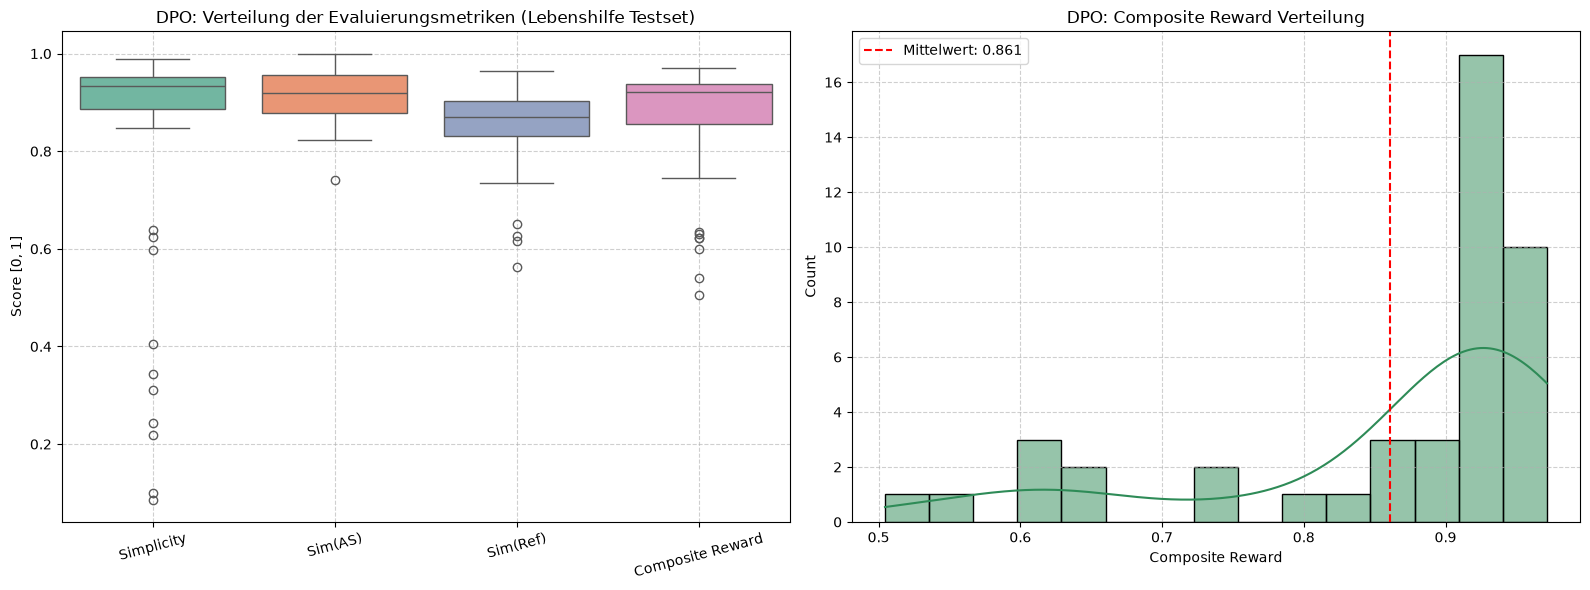

In [9]:
os.makedirs("results/plots", exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Boxplot der Metriken
sns.boxplot(data=dpo_eval_df[metrics_cols], ax=axes[0], palette="Set2")
axes[0].set_title("DPO: Verteilung der Evaluierungsmetriken (Lebenshilfe Testset)", fontsize=12)
axes[0].set_ylabel("Score [0, 1]")
axes[0].set_xticklabels(["Simplicity", "Sim(AS)", "Sim(Ref)", "Composite Reward"], rotation=15)
axes[0].grid(True, linestyle="--", alpha=0.6)

# 2. KDE / Histogramm des Composite Rewards
sns.histplot(dpo_eval_df["composite_reward"], kde=True, ax=axes[1], color="seagreen", bins=15)
axes[1].axvline(dpo_eval_df["composite_reward"].mean(), color="red", linestyle="--", label=f"Mittelwert: {dpo_eval_df['composite_reward'].mean():.3f}")
axes[1].set_title("DPO: Composite Reward Verteilung", fontsize=12)
axes[1].set_xlabel("Composite Reward")
axes[1].legend()
axes[1].grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plot_out_path = "results/plots/dpo_lebenshilfe_metrics.png"
plt.savefig(plot_out_path, dpi=300)
print(f"Plot gespeichert unter: {plot_out_path}")
plt.show()

## 8. Interaktiver Übersetzungstest

In [10]:
def translate_custom_text(text):
    inputs = tokenizer(text, return_tensors="pt", max_length=MAX_SOURCE_LEN, truncation=True).to(DEVICE)
    forced_bos_id = tokenizer.lang_code_to_id.get("de_DE", None) if hasattr(tokenizer, "lang_code_to_id") else None
    
    gen_kwargs = {
        "input_ids": inputs["input_ids"],
        "attention_mask": inputs.get("attention_mask"),
        "max_length": MAX_TARGET_LEN,
        "num_beams": 4,
        "repetition_penalty": 2.5,
        "no_repeat_ngram_size": 3,
        "early_stopping": True,
        "forced_bos_token_id": forced_bos_id
    }
    
    with torch.no_grad():
        # 1. SFT-Übersetzung generieren (LoRA-Adapter temporär deaktiviert)
        if hasattr(dpo_model, "disable_adapter"):
            with dpo_model.disable_adapter():
                sft_ids = dpo_model.generate(**gen_kwargs)
        elif "base_model" in globals() and base_model is not None and base_model is not dpo_model:
            sft_ids = base_model.generate(**gen_kwargs)
        else:
            sft_ids = None

        # 2. DPO-Übersetzung generieren (mit aktiven DPO-Adaptern)
        dpo_ids = dpo_model.generate(**gen_kwargs)
    
    dpo_translation = tokenizer.decode(dpo_ids[0], skip_special_tokens=True).strip()
    dpo_tot_reward, dpo_r_style, dpo_r_sem_norm = reward_evaluator.compute_reward([text], [dpo_translation])
    
    print("=" * 80)
    print(f"[Eingabe (AS)]:\n{text}\n")
    
    sft_translation = None
    if sft_ids is not None:
        sft_translation = tokenizer.decode(sft_ids[0], skip_special_tokens=True).strip()
        sft_tot_reward, sft_r_style, sft_r_sem_norm = reward_evaluator.compute_reward([text], [sft_translation])
        print(f"-> [SFT-Basismodell]:\n{sft_translation}")
        print(f"   Scores: Style={sft_r_style[0]:.3f} | SBERT={sft_r_sem_norm[0]:.3f} | Total Reward={sft_tot_reward[0]:.3f}\n")
    
    print(f"-> [DPO-Feinjustiert]:\n{dpo_translation}")
    print(f"   Scores: Style={dpo_r_style[0]:.3f} | SBERT={dpo_r_sem_norm[0]:.3f} | Total Reward={dpo_tot_reward[0]:.3f}")
    print("=" * 80 + "\n")
    
    return {
        "sft": sft_translation,
        "dpo": dpo_translation
    }

# Beispiel testen:
test_input = "Das Arbeitslosengeld dient der Sicherung des Lebensunterhalts während der Arbeitslosigkeit und wird nach bestimmten Kriterien bewilligt."
test_input_hund = "Hunde (Canis lupus familiaris) begleiten den Menschen seit Jahrtausenden und gelten als das älteste domestizierte Haustier. Sie stammen vom Wolf ab und haben sich im Laufe der Zeit perfekt an das Leben mit uns angepasst. Heute sind sie nicht nur beliebte Haustiere, sondern oft vollwertige Familienmitglieder, ausdauernde Arbeitstiere und therapeutische Helfer."

translate_custom_text(test_input)
translate_custom_text(test_input_hund);


[Eingabe (AS)]:
Das Arbeitslosengeld dient der Sicherung des Lebensunterhalts während der Arbeitslosigkeit und wird nach bestimmten Kriterien bewilligt.

-> [SFT-Basismodell]:
Wie bekomme ich Arbeitslosengeld?
   Scores: Style=0.680 | SBERT=0.826 | Total Reward=0.753

-> [DPO-Feinjustiert]:
Wie bekomme ich Arbeitslosengeld?
   Scores: Style=0.680 | SBERT=0.826 | Total Reward=0.753

[Eingabe (AS)]:
Hunde (Canis lupus familiaris) begleiten den Menschen seit Jahrtausenden und gelten als das älteste domestizierte Haustier. Sie stammen vom Wolf ab und haben sich im Laufe der Zeit perfekt an das Leben mit uns angepasst. Heute sind sie nicht nur beliebte Haustiere, sondern oft vollwertige Familienmitglieder, ausdauernde Arbeitstiere und therapeutische Helfer.

-> [SFT-Basismodell]:
Hunde begleiten uns seit vielen Jahren. Sie sind das älteste Haustier von Menschen. Hunde gehören zu der Familie von Hunden. Die Familienmitglieder sind oft sehr ausdauernde Arbeitstiere und therapeutische Helfer. 